### Blood subtypes

In [106]:
suppressPackageStartupMessages(library(SingleCellExperiment))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(argparse))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(batchelor))
suppressPackageStartupMessages(library(destiny))


#####################
## Define settings ##
#####################
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))
source(here::here("mapping/run/mnn/mapping_functions.R"))

args = list()
args$sce <- io$rna.sce
#args$stage <- c('E9.5')#, 'E8.5', 'E9.5')
args$metadata <- paste0(io$basedir,"/results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$atlas_metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/sample_metadata.txt.gz"
args$outdir <- paste0(io$basedir,"/results/rna/blood")
args$metascape = file.path(args$outdir, 'metascape')
# If passing multiple timepoints split in vector
#args$stage = strsplit(args$stage, "_")[[1]] 

dir.create(args$metascape, recursive=TRUE, showWarnings = FALSE)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/code



In [2]:
ct_blood = c('Haematoendothelial progenitors',
             'Blood progenitors',
             'Erythroid')


##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
   .[pass_rnaQC==TRUE & doublet_call==FALSE & celltype.mapped_mnn %in% ct_blood] %>%
    .[,pool:=stringr::str_replace_all(sample,opts$sample2pool)]


# if(test){
#     sample_metadata = sample_metadata[sample(1:nrow(sample_metadata), nrow(sample_metadata)/4)]
# }

###############
## Load data ##
###############

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

In [3]:
sce

class: SingleCellExperiment 
dim: 29453 3174 
metadata(0):
assays(2): counts logcounts
rownames(29453): Xkr4 Gm1992 ... CAAA01147332.1 tomato-td
rowData names(0):
colnames(3174): SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1
  SLX-21143_SITTA2_HTJH3DSX2#AAACGAACACACCAGC-1 ...
  SLX-21143_SITTH3_HTJH3DSX2#TTTCGATAGCTCATAC-1
  SLX-21143_SITTH3_HTJH3DSX2#TTTGGTTGTTAGCTAC-1
colData names(19): sample barcode ... tdTom_corr pool
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [4]:
#######################
## Feature selection ##
#######################

decomp <- modelGeneVar(sce)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- rownames(decomp)[decomp$p.value <= 0.01]

# Subset HVGs
sce_filt <- sce[hvgs,]
dim(sce_filt)

sce_filt <- runPCA(sce_filt, ncomponents = 20, ntop=nrow(sce_filt))

[1]  646 3174

In [21]:
pca = as.data.frame(reducedDim(sce_filt, "PCA"))

In [25]:
dm <- DiffusionMap(pca, n_pcs=20)
# Add to the SingleCellExperiment object
reducedDim(sce_filt, "DiffusionMap") <- dm@eigenvectors[,c(1,2)]

In [ ]:
opts$celltype

Scale for 'colour' is already present. Adding another scale for 'colour',
which will replace the existing scale.

Scale for 'colour' is already present. Adding another scale for 'colour',
which will replace the existing scale.



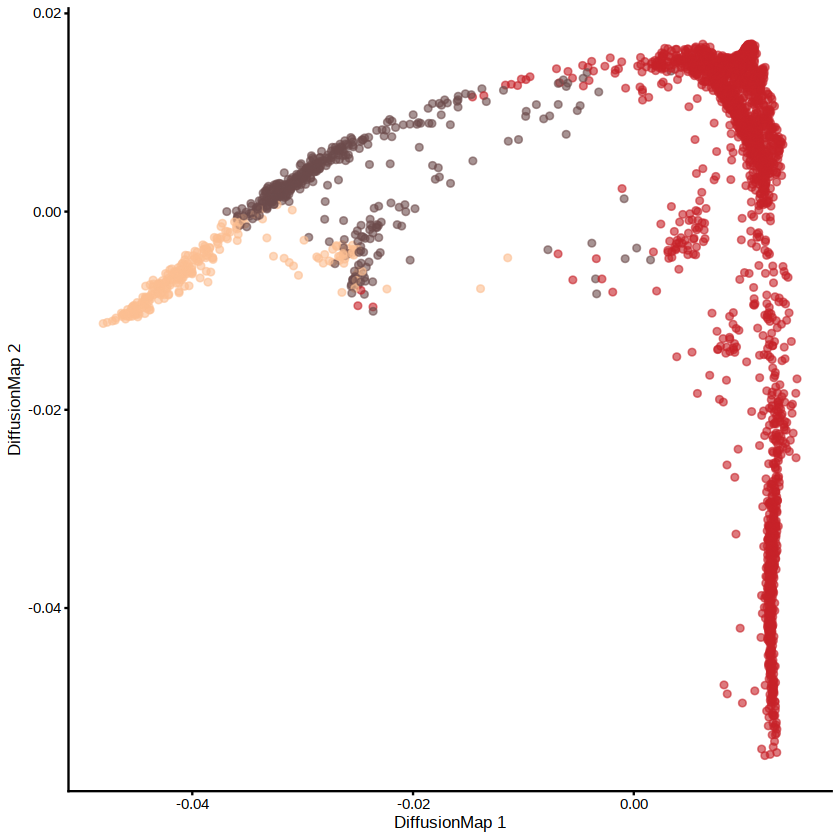

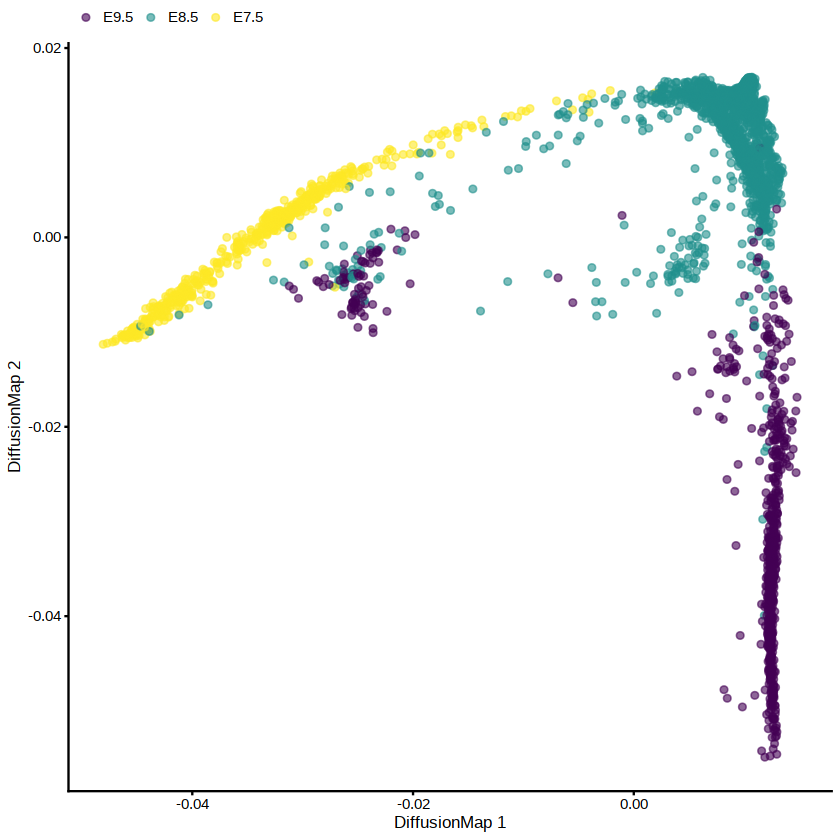

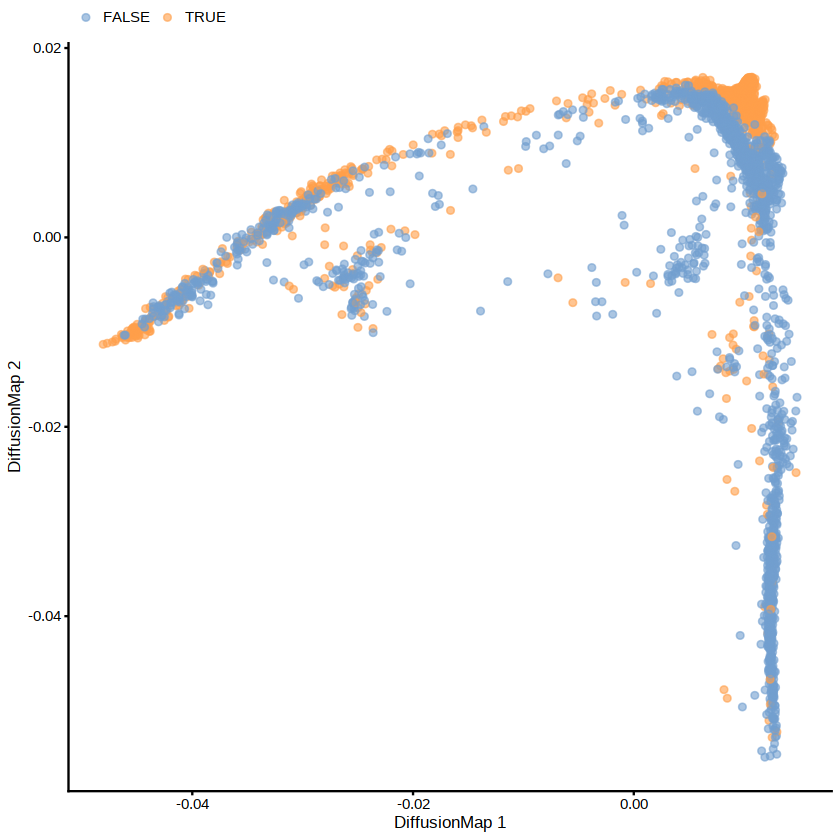

In [28]:
# Plot
plotReducedDim(sce_filt, dimred = "DiffusionMap", colour_by="celltype.mapped_mnn", ncomponents = c(1,2)) +
  scale_colour_manual(values=opts$celltype.colors) + theme(legend.position="none")

plotReducedDim(sce_filt, dimred = "DiffusionMap", colour_by="stage", ncomponents = c(1,2)) +
  scale_colour_manual(values=opts$stage.colors) + theme(legend.position="top", legend.title = element_blank())

plotReducedDim(sce_filt, dimred = "DiffusionMap", colour_by="tdTom_corr", ncomponents = c(1,2)) +
  theme(legend.position="top", legend.title = element_blank())

In [29]:
colnames(colData(sce))

[1] "sample"                    "barcode"                  
 [3] "nFeature_RNA"              "nCount_RNA"               
 [5] "mitochondrial_percent_RNA" "ribosomal_percent_RNA"    
 [7] "stage"                     "tdTom"                    
 [9] "pass_rnaQC"                "doublet_score"            
[11] "doublet_call"              "celltype.mapped_mnn"      
[13] "celltype.score_mnn"        "stage.mapped_mnn"         
[15] "cellstage.score_mnn"       "closest.cell_mnn"         
[17] "idx"                       "tdTom_corr"               
[19] "pool"

# Batch correction by sample

In [4]:
decomp <- modelGeneVar(sce, block=colData(sce)$sample)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=5000) %>% rownames

# Subset SingleCellExperiment
sce_filt <- sce[hvgs,]

# PCA
pca.list <- multiBatchPCA(sce_filt, batch = colData(sce_filt)$sample, d = 15, preserve.single=FALSE)
# batch correction 
pca.corrected <- reducedMNN(pca.list, merge.order=1:length(pca.list))$corrected 


Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”
Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”
Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”


In [5]:
dm <- DiffusionMap(pca.corrected, n_pcs=15)
# Add to the SingleCellExperiment object
reducedDim(sce_filt, "DiffusionMap") <- dm@eigenvectors[,c(1,2)]

Scale for 'colour' is already present. Adding another scale for 'colour',
which will replace the existing scale.

Scale for 'colour' is already present. Adding another scale for 'colour',
which will replace the existing scale.



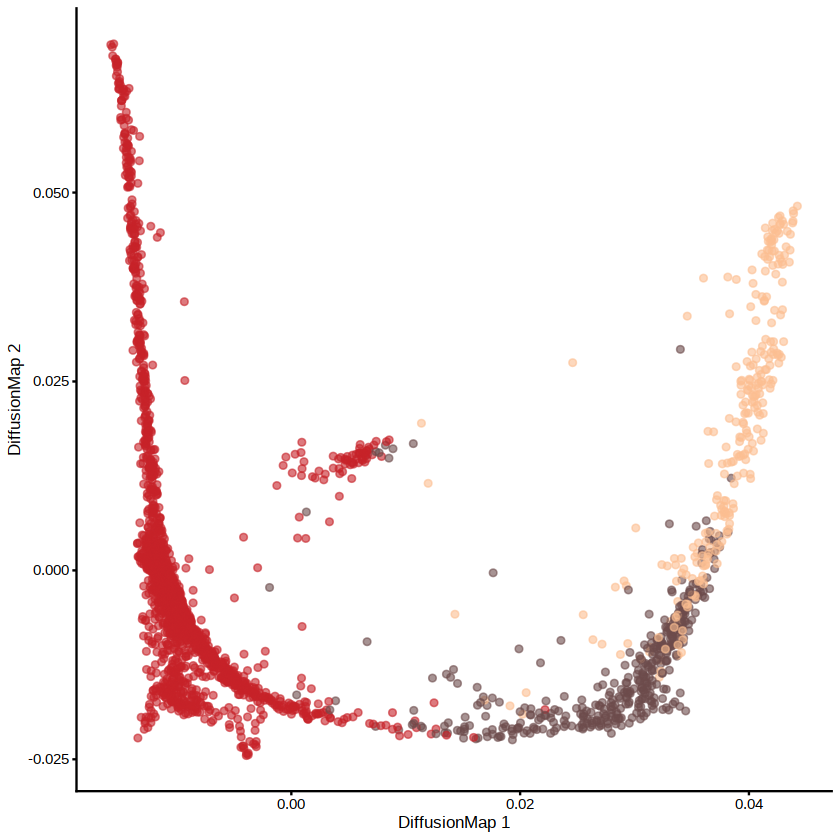

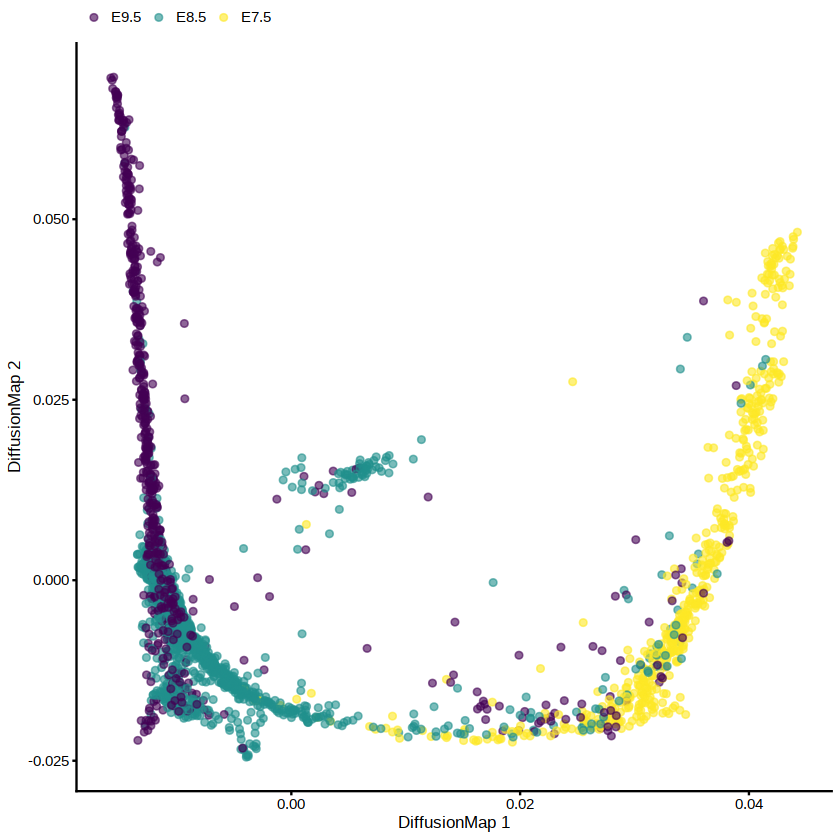

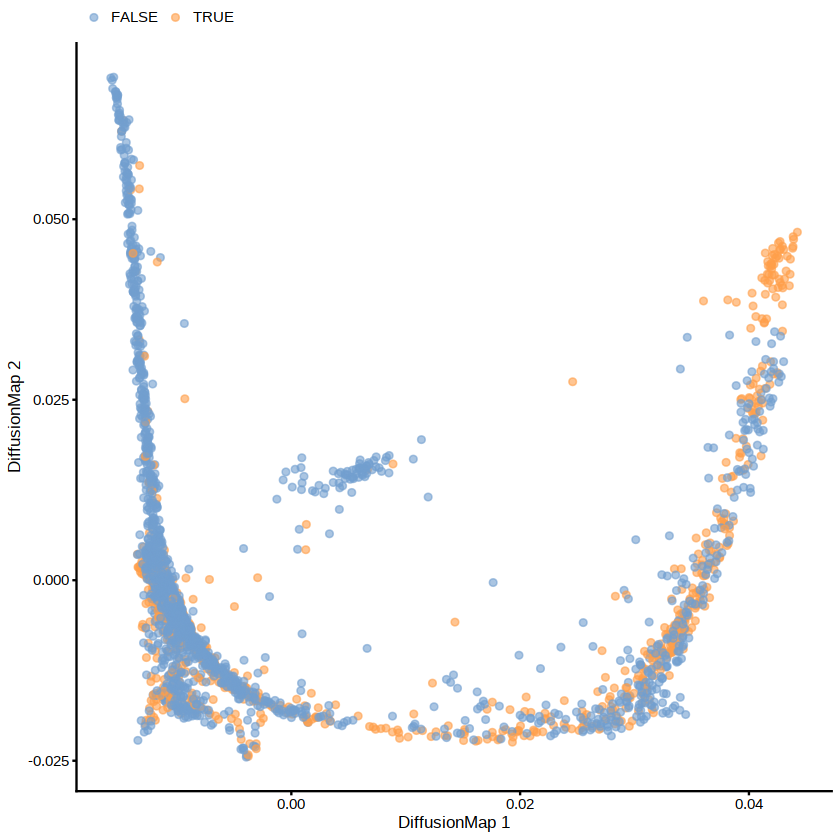

In [6]:
# Plot
plotReducedDim(sce_filt, dimred = "DiffusionMap", colour_by="celltype.mapped_mnn", ncomponents = c(1,2)) +
  scale_colour_manual(values=opts$celltype.colors) + theme(legend.position="none")

plotReducedDim(sce_filt, dimred = "DiffusionMap", colour_by="stage", ncomponents = c(1,2)) +
  scale_colour_manual(values=opts$stage.colors) + theme(legend.position="top", legend.title = element_blank())

plotReducedDim(sce_filt, dimred = "DiffusionMap", colour_by="tdTom_corr", ncomponents = c(1,2)) +
  theme(legend.position="top", legend.title = element_blank())

#### check gene expression

In [7]:
head(hvgs, 20)

[1] "Mgst3"    "Car2"     "Alad"     "Cited4"   "Id3"      "Mest"    
 [7] "Apoe"     "Blvrb"    "Hbb-bs"   "Hbb-bh1"  "Hbb-y"    "H19"     
[13] "Phlda2"   "Cited2"   "Rspo3"    "Mt1"      "Hba-x"    "Hba-a1"  
[19] "Hba-a2"   "Hist1h1b"

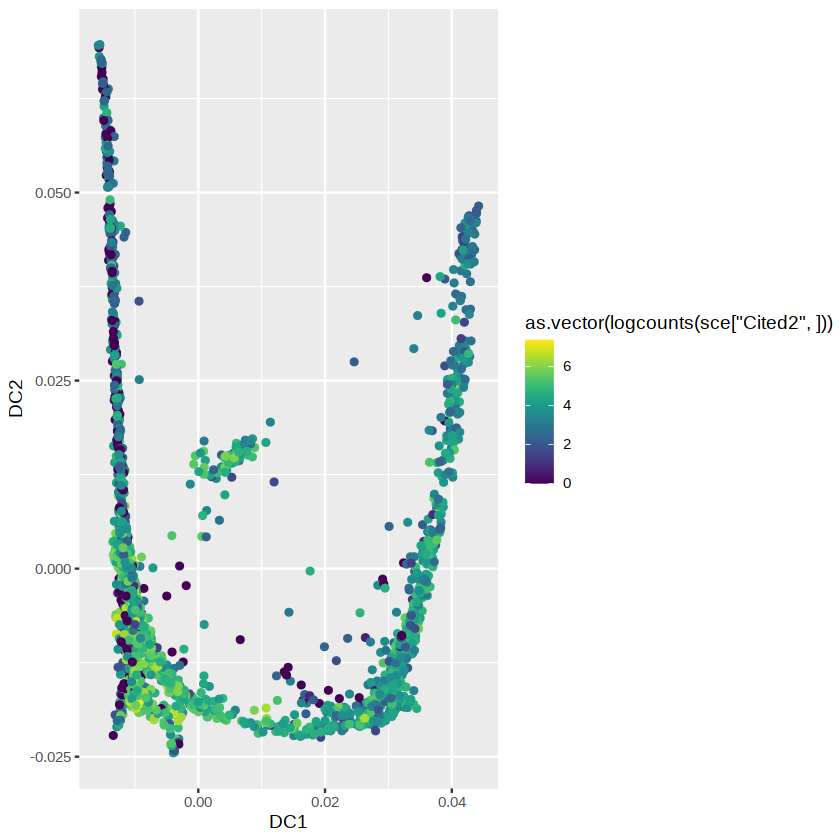

In [8]:
ggplot(as.data.frame(dm@eigenvectors[,c(1,2)]), aes(DC1, DC2, col=as.vector(logcounts(sce['Cited2',])))) + geom_point() + viridis::scale_color_viridis()

# Pseudotime inference
https://www.bioconductor.org/packages/release/bioc/vignettes/tradeSeq/inst/doc/tradeSeq.html
https://www.bioconductor.org/packages/release/bioc/manuals/tradeSeq/man/tradeSeq.pdf

In [9]:
suppressPackageStartupMessages(library(tradeSeq))
suppressPackageStartupMessages(library(slingshot))

In [10]:
reducedDim(sce_filt, "PCA") = pca.corrected

In [11]:
sce_filt <- slingshot(sce_filt, reducedDim='PCA')
head(sce_filt$slingPseudotime_1)

No cluster labels provided. Continuing with one cluster.



[1] 22.15106 24.88265 30.68417 31.32416 27.37315 36.96189

In [12]:
embedded <- embedCurves(sce_filt, "DiffusionMap")
embedded <- slingCurves(embedded)[[1]] # only 1 path.
embedded <- data.frame(embedded$s[embedded$ord,])

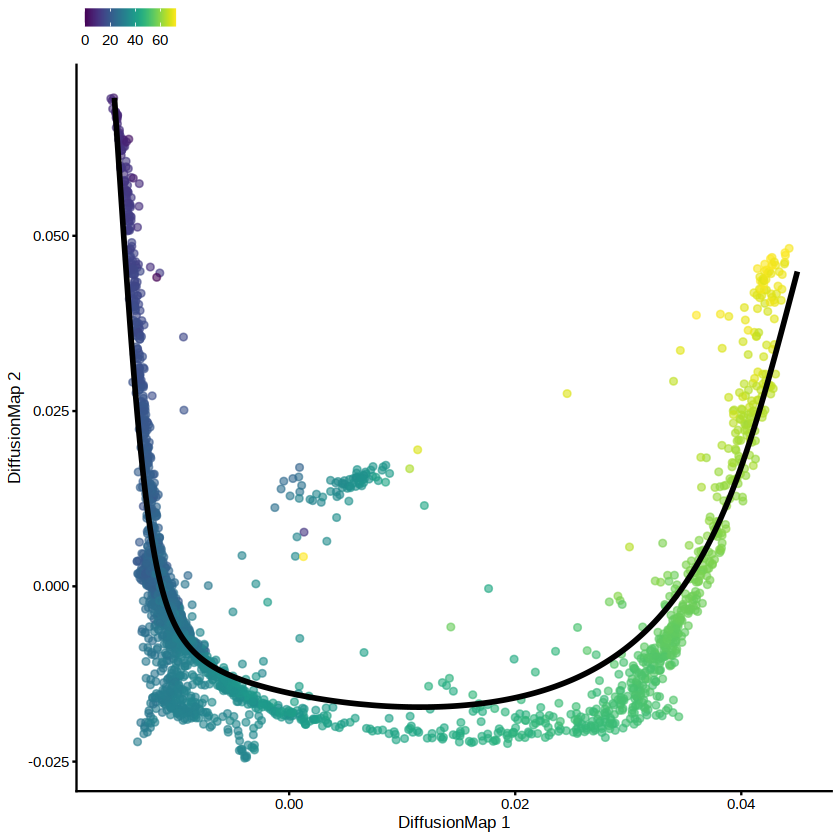

In [13]:
plotReducedDim(sce_filt, dimred = "DiffusionMap", colour_by="slingPseudotime_1", ncomponents = c(1,2)) +
  geom_path(data=embedded, aes(x=DC1, y=DC2), size=1.2) + theme(legend.position="top", legend.title = element_blank())

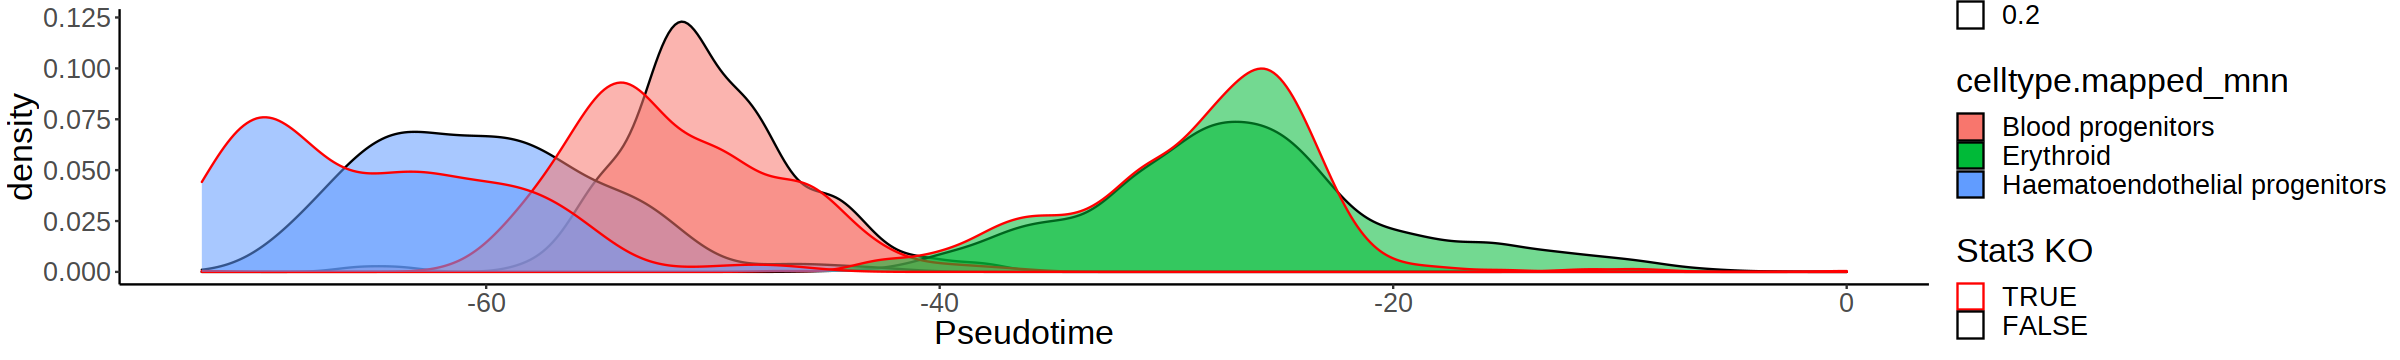

In [108]:
options(repr.plot.width=20, repr.plot.height=3)

meta = as.data.frame(colData(sce_filt)[,-20])
p = ggplot(meta, aes(-slingPseudotime_1, col=tdTom_corr, fill=celltype.mapped_mnn, alpha=0.2)) + 
    geom_density() + 
    scale_colour_manual(values=c('TRUE'='red', 'FALSE'='black'), name='Stat3 KO') + 
    xlab('Pseudotime') +
    theme_classic() +
    theme(text=element_text(size=20))
p

In [111]:
pdf(sprintf('%s/blood_pseudotime.pdf', args$outdir), height=3, width=15)
    p
dev.off()

png 
  2

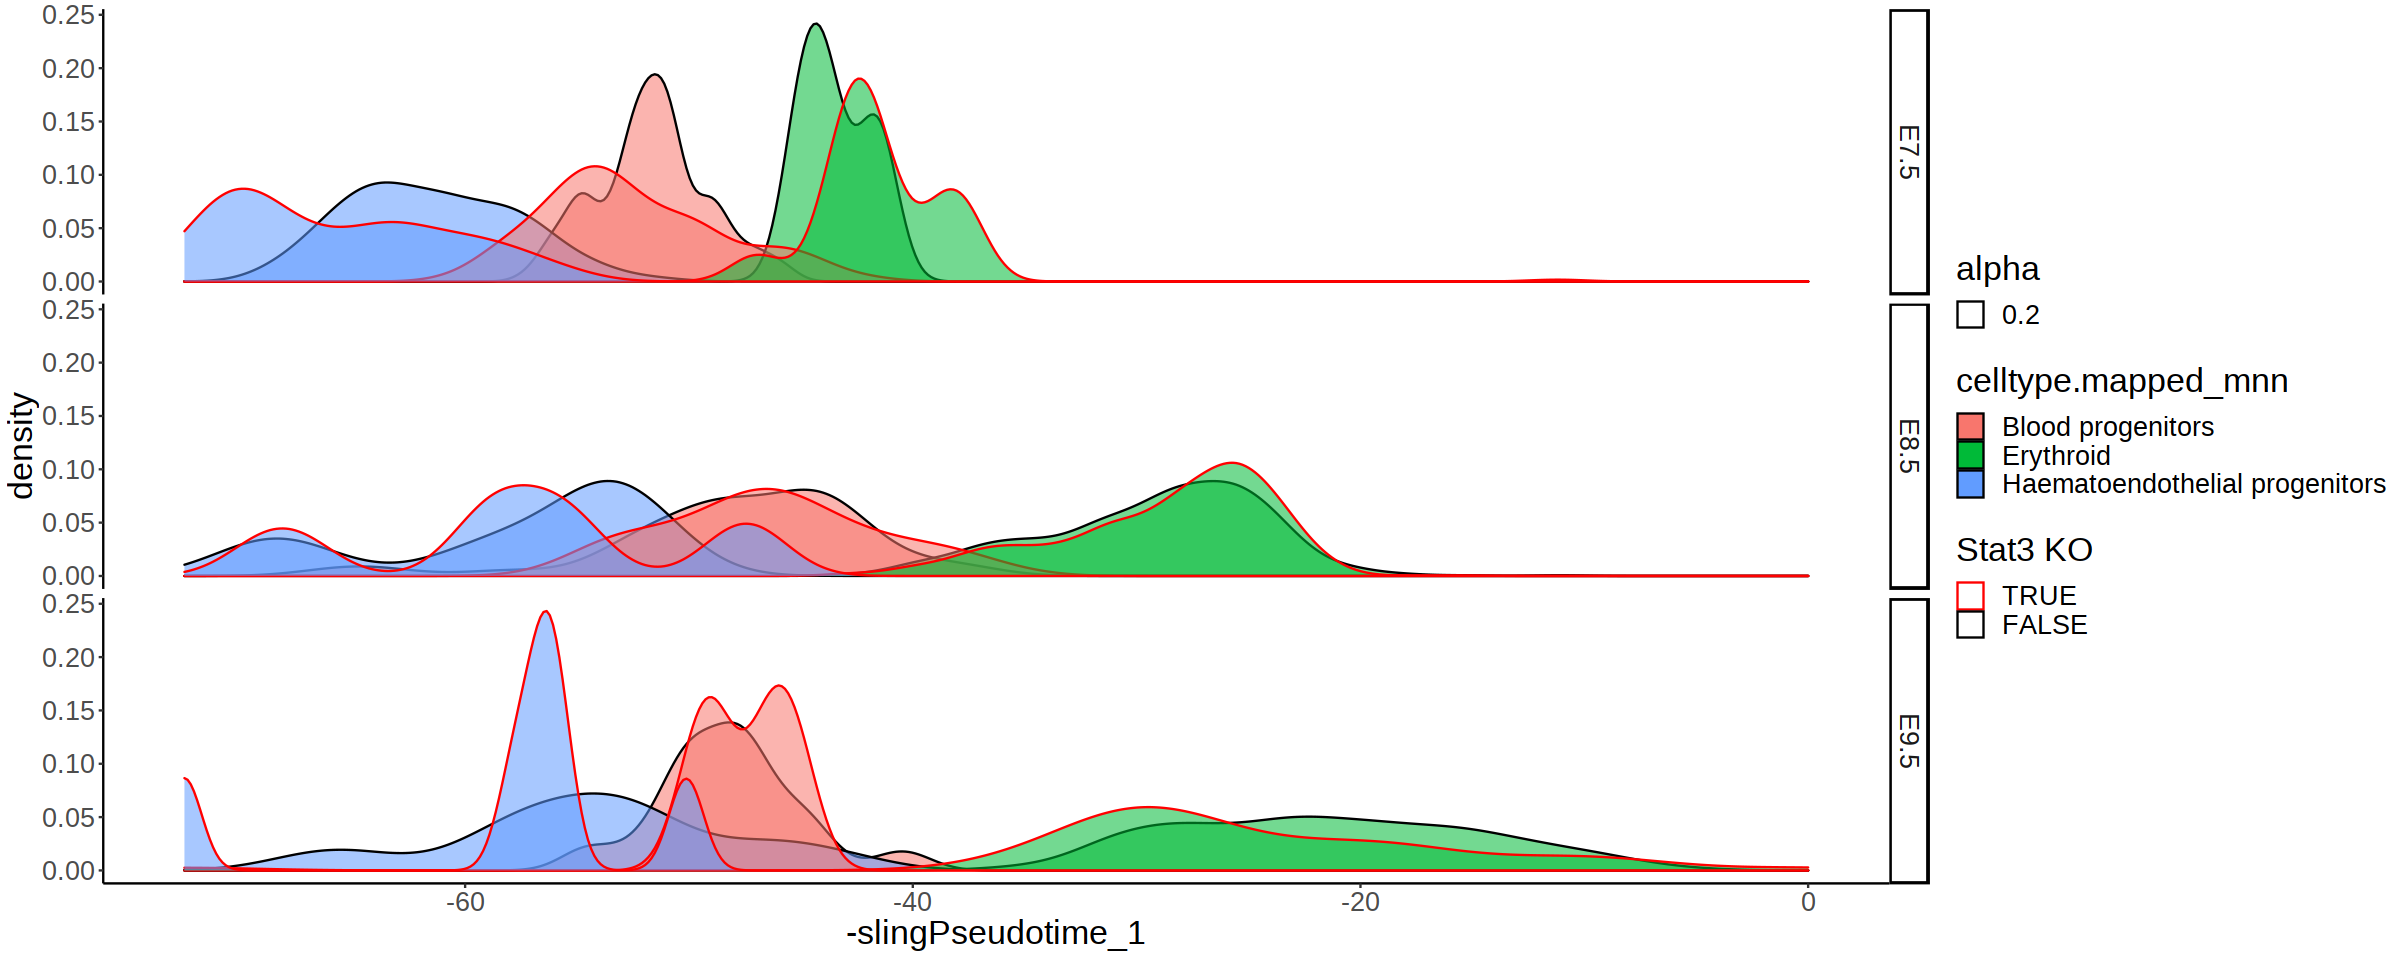

In [86]:
meta = as.data.frame(colData(sce_filt)[,-20])
options(repr.plot.width=20, repr.plot.height=8)
ggplot(meta, aes(-slingPseudotime_1, col=tdTom_corr, fill=celltype.mapped_mnn, alpha=0.2)) + 
    geom_density() + 
    scale_colour_manual(values=c('TRUE'='red', 'FALSE'='black'), name='Stat3 KO') + 
    facet_grid(rows=vars(stage)) + 
    theme_classic() + 
    theme(text=element_text(size=20))

# Trade-seq

In [15]:
cellWeights <- rep(1,ncol(sce_filt))

# test with tdTom instead of Corr to see if this fixes problem!

In [16]:
# create a model matrix
U <- model.matrix(~sce_filt$pool)

In [17]:
sce_filt$slingPseudotime_1 = round(sce_filt$slingPseudotime_1, 2)

In [17]:
set.seed(5)
sceGAM <- fitGAM(counts = counts(sce_filt),
                 conditions = as.factor(sce_filt$tdTom_corr),
                 U = U,
                 pseudotime= sce_filt$slingPseudotime_1,
                 cellWeights=cellWeights,
                 nknots=6,
             #    BPPARAM=MulticoreParam(workers=20),
                 verbose=F)

Fitting lineages with multiple conditions. This method has been tested on a couple of datasets, but is still in an experimental phase.



In [18]:
saveRDS(sceGAM, paste0(io$basedir,"/results/rna/sceGAM.rds"))

In [19]:
condRes <- conditionTest(sceGAM, l2fc = 0.5)
condRes$padj <- p.adjust(condRes$pvalue, "fdr")

In [20]:
condRes = condRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>%
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] %>%
    .[order(padj, -waldStat)]

In [21]:
head(condRes$gene, 100)

[1] "H19"           "Gm42418"       "Hba-x"         "Hbb-bh1"      
  [5] "Hba-a1"        "Csf2rb"        "Pim1"          "Hist1h4i"     
  [9] "Xist"          "Fabp5"         "Akr1e1"        "Zfp985"       
 [13] "Olfm1"         "Cwc22"         "Cap2"          "Hbb-y"        
 [17] "Grb10"         "Podxl"         "Cish"          "Ccnb1ip1"     
 [21] "Lrmp"          "Kdm5d"         "Pik3r1"        "Myb"          
 [25] "Plek2"         "Hba-a2"        "Igf1r"         "Rnf17"        
 [29] "Bdh1"          "Clic6"         "Stat5a"        "Rasl11a"      
 [33] "Gata2"         "Hmga2"         "Slc5a2"        "Mest"         
 [37] "Stat5b"        "Mgst2"         "Mt2"           "Cd24a"        
 [41] "Ahnak"         "Basp1"         "Blvrb"         "1700048O20Rik"
 [45] "Rgcc"          "Ptpn18"        "Igf2"          "Ccnd2"        
 [49] "Rbms1"         "Serpinh1"      "Meis2"         "Tsix"         
 [53] "Tead2"         "Cdh2"          "Gm8113"        "Gm45890"      
 [57] "Vamp5"         "Tnfaip2"       "Tnfrsf14"      "Hmox1"        
 [61] "2200002D01Rik" "Ly6e"          "Tyrobp"        "Atp2a3"       
 [65] "Fbln1"         "Lgals3"        "Inf2"          "Ston2"        
 [69] "Pde1c"         "Vcan"          "Gm44791"       "Enpp1"        
 [73] "Gjc1"          "Srgn"          "Spef1"         "Prtg"         
 [77] "Id2"           "Tcf15"         "Crabp1"        "Ptpre"        
 [81] "Ccnd1"         "Twist1"        "Cacna2d2"      "Zfp979"       
 [85] "Wnk3"          "Hormad2"       "Esx1"          "Tgfb1"        
 [89] "Sema6a"        "Plac8"         "Tubb1"         "Xaf1"         
 [93] "Hebp1"         "Lst1"          "Hoxb4"         "Hemgn"        
 [97] "Cd52"          "Itga8"         "Paqr7"         "5430416O09Rik"

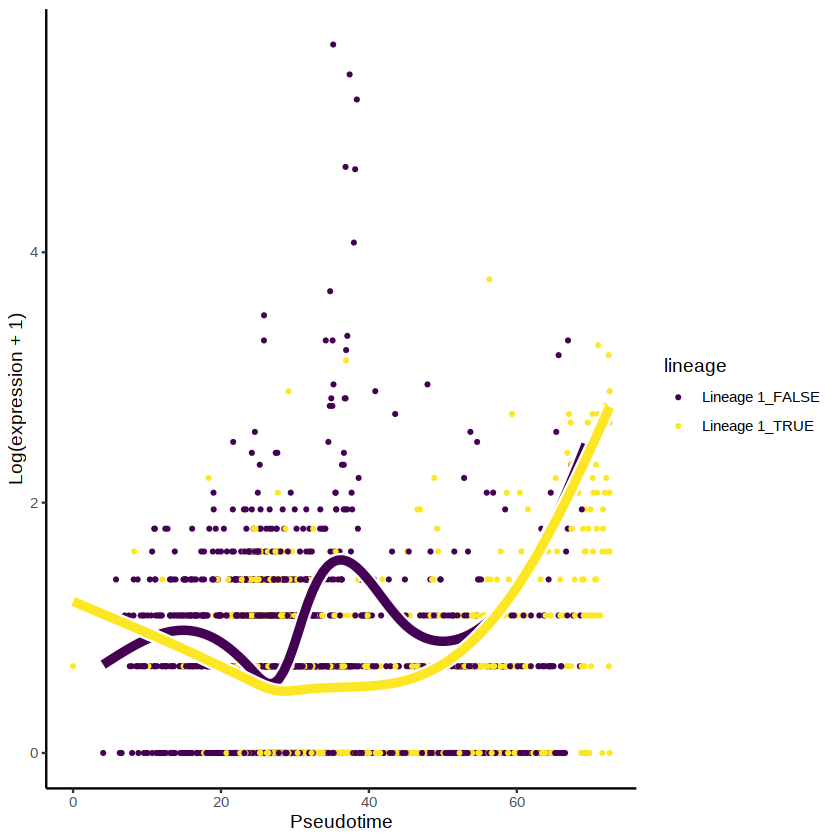

In [32]:
plotSmoothers(sceGAM, as.matrix(assays(sceGAM)$counts),  'Crabp1')

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



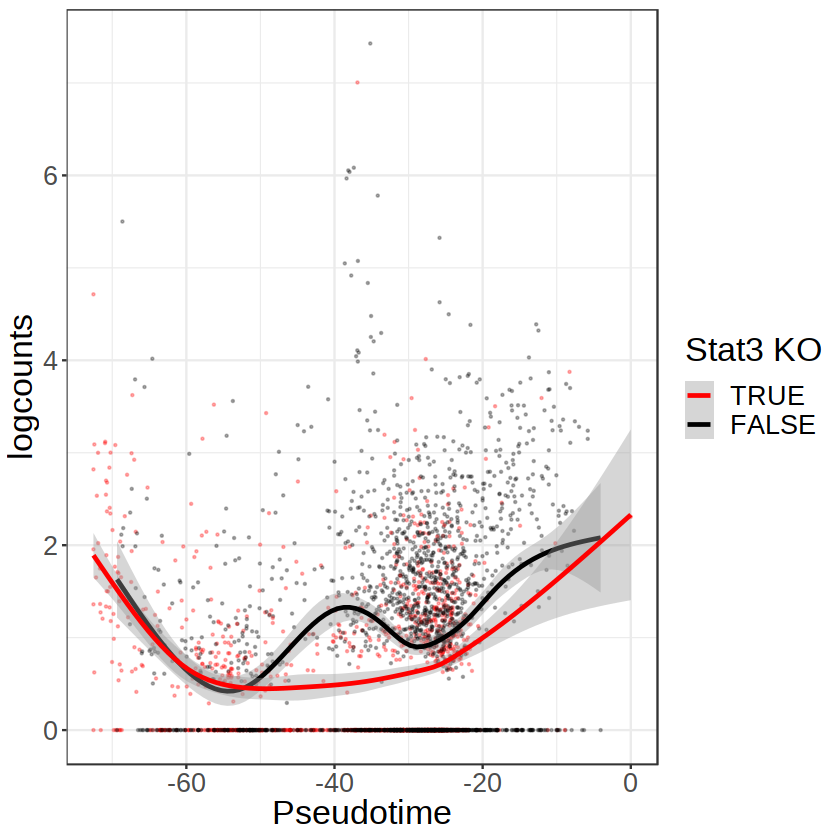

In [33]:
ggplot(as.data.frame(colData(sce_filt)[,-20]), aes(-slingPseudotime_1, as.vector(logcounts(sce_filt['Crabp1',])), col=tdTom_corr)) + 
    geom_point(size=0.2, alpha=0.3) + 
    geom_smooth() + 
    scale_colour_manual(values=c('TRUE'='red', 'FALSE'='black'), name='Stat3 KO') + 
    ylab('logcounts') + 
    xlab('Pseudotime') + 
    theme_bw() + 
    theme(text=element_text(size=20))

# Pseudotime as ranking of pseudotime to remove cell density issue

In [17]:
# this works much better, so probably just solving the pseudotime will fix my issues

In [26]:
sce_filt = sce_filt[,order(sce_filt$slingPseudotime_1)]
sce_filt$pseudotime_rank = 1:ncol(sce_filt)

In [28]:
set.seed(5)
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

sceGAM <- fitGAM(counts = counts(sce_filt),
                 conditions = as.factor(sce_filt$tdTom_corr),
                 U = U,
                 pseudotime= sce_filt$pseudotime_rank,
                 cellWeights=cellWeights,
                 nknots=6,
                 parallel = TRUE,
                 BPPARAM=BPPARAM,
                 verbose=F)

Fitting lineages with multiple conditions. This method has been tested on a couple of datasets, but is still in an experimental phase.



In [29]:
condRes <- conditionTest(sceGAM, l2fc = 0.5)
condRes$padj <- p.adjust(condRes$pvalue, "fdr")

In [30]:
condRes = condRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>%
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] %>%
    .[order(padj, -waldStat)]

In [70]:
head(condRes[sig==TRUE]$gene, 200)

[1] "Grb10"         "Cd59a"         "H19"           "Hba-x"        
  [5] "Fabp5"         "Xist"          "Pim1"          "Csf2rb"       
  [9] "Hba-a1"        "Hist1h4i"      "Pnpo"          "Gm44791"      
 [13] "Plin2"         "Hbb-bh1"       "Gm42418"       "Bpgm"         
 [17] "Hbb-y"         "Cwc22"         "Fgf3"          "Akr1e1"       
 [21] "Cap2"          "Tmem14c"       "Ccnb1ip1"      "Mest"         
 [25] "Fam210b"       "Hba-a2"        "Zfp985"        "Crabp1"       
 [29] "AY036118"      "Mt1"           "Nrgn"          "Eif3j1"       
 [33] "Olfm1"         "Prr13"         "Id3"           "4930523C07Rik"
 [37] "Rragd"         "Lmo2"          "Gm10320"       "Plek2"        
 [41] "Hesx1"         "Basp1"         "Fam117b"       "Gmpr"         
 [45] "Stat5a"        "Spink1"        "Hmga2"         "Lrmp"         
 [49] "Podxl"         "Ccnd2"         "Kdm5d"         "Rnf17"        
 [53] "Ubash3b"       "Stat5b"        "Cish"          "Ptn"          
 [57] "C1qtnf4"       "2200002D01Rik" "Tsix"          "Rfesd"        
 [61] "Atp1b2"        "Itga4"         "Krt15"         "Mt2"          
 [65] "Def6"          "Hist1h2bj"     "Gm45890"       "Tagln2"       
 [69] "Tmem184a"      "Hectd1"        "Meis2"         "Bdh1"         
 [73] "Hist1h2ae"     "Sox4"          "Crabp2"        "Twist1"       
 [77] "Cd24a"         "Hhex"          "Sox11"         "Gm8113"       
 [81] "Myb"           "Pik3r1"        "Gjc1"          "Fermt3"       
 [85] "Ptrf"          "Pycr2"         "Tnni1"         "Vcan"         
 [89] "Hbb-bt"        "Hist1h4d"      "Arhgdib"       "Dlk1"         
 [93] "Lmx1a"         "Syne2"         "Igdcc3"        "Ttr"          
 [97] "Nab1"          "Jun"           "Itpka"         "Mthfd2"       
[101] "Sfrp1"         "Fn3k"          "Eif3j2"        "Id2"          
[105] "Hist1h3c"      "Cdh2"          "Nr2f1"         "Igtp"         
[109] "Ccnd1"         "Pklr"          "Cdkn1c"        "Rasl11a"      
[113] "1700048O20Rik" "Bcl11b"        "Igf1r"         "Rpl26"        
[117] "H2-K1"         "Fermt2"        "Gata2"         "Srgn"         
[121] "Prrx2"         "Selenow"       "Slc5a2"        "Prtn3"        
[125] "Palld"         "Tead2"         "Tubb2b"        "Hmgn3"        
[129] "Lcp1"          "Tinagl1"       "Csf2rb2"       "Ptpn18"       
[133] "Isg15"         "Fam25c"        "Rbms1"         "Hoxaas3"      
[137] "Hoxb4"         "Lrp1"          "Hist1h3e"      "Hmox1"        
[141] "Tuba1a"        "S100a10"       "Zfp979"        "Gpc3"         
[145] "Coro1a"        "Fzd2"          "Rasgrp2"       "Igf2"         
[149] "Pax3"          "Ckap4"         "Col1a1"        "Ckb"          
[153] "Hdgfrp3"       "Tnfrsf14"      "Hist2h2ac"     "Tgm2"         
[157] "Fn1"           "Sox2"          "Vim"           "Epha4"        
[161] "Fam181b"       "Plagl1"        "Plac8"         "Ptpn7"        
[165] "Rhox5"         "Fgf15"         "H2afy2"        "5430416O09Rik"
[169] "Serpinh1"      "Hormad2"       "Ubb"           "Fbn2"         
[173] "Fbln1"         "Dst"           "Pde1c"         "Hoxa7"        
[177] "F10"           "Tnfaip2"       "1700097N02Rik" "Nav1"         
[181] "Ikzf2"         "Hcn3"          "Nrep"          "Vamp5"        
[185] "BC049730"      "Lef1"          "S100a11"       "Lpp"          
[189] "Tubb1"         "Apoa1"         "Lbp"           "Nkx2-5"       
[193] "Nrp1"          "Crlf1"         "Enpp1"         "Marcks"       
[197] "Ncf4"          "Rac2"          "Tox3"          "Nrros"

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



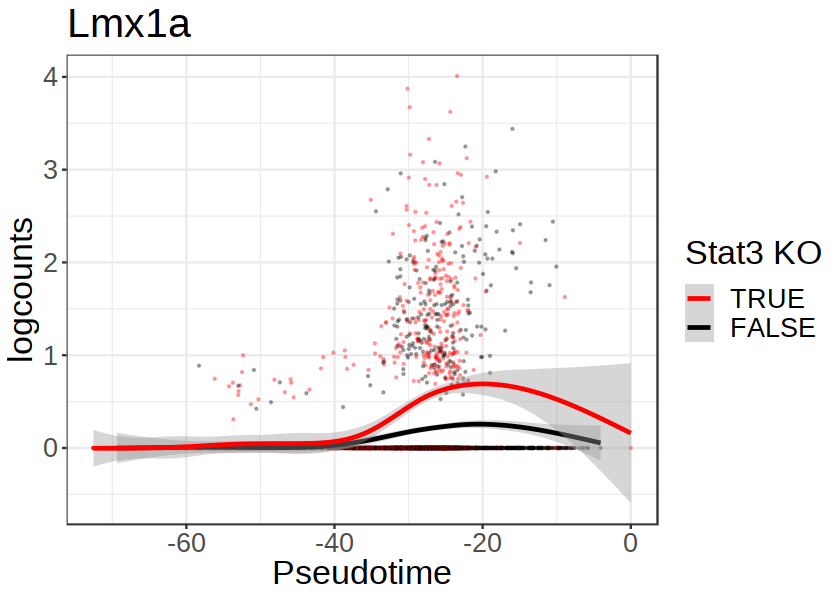

In [76]:
gene = 'Lmx1a'
options(repr.plot.width=7, repr.plot.height=5)

#ggarrange(
#plotSmoothers(sceGAM, as.matrix(assays(sceGAM)$counts),  gene),
ggplot(as.data.frame(colData(sce_filt)[,-20]), aes(-slingPseudotime_1, as.vector(logcounts(sce_filt[gene,])), col=tdTom_corr)) + 
    geom_point(size=0.2, alpha=0.3) + 
    geom_smooth() + 
    scale_colour_manual(values=c('TRUE'='red', 'FALSE'='black'), name='Stat3 KO') + 
    ylab('logcounts') + 
    xlab('Pseudotime') + 
    ggtitle(gene) + 
    theme_bw() + 
    theme(text=element_text(size=20))#,
# ggplot(as.data.frame(colData(sce_filt)[,-20]), aes(-pseudotime_rank, as.vector(logcounts(sce_filt[gene,])), col=tdTom_corr)) + 
#     geom_point(size=0.2, alpha=0.3) + 
#     geom_smooth() + 
#     scale_colour_manual(values=c('TRUE'='red', 'FALSE'='black'), name='Stat3 KO') + 
#     ylab('logcounts') + 
#     xlab('Pseudotime') + 
#     theme_bw() + 
#     theme(text=element_text(size=20)),
#     ncol=3
#     )

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

Warning message:
“Computation failed in `stat_smooth()`:
NA/NaN/Inf in foreign function call (arg 3)”
Warning message:
“Computation failed in `stat_smooth()`:
NA/NaN/Inf in foreign function call (arg 3)”


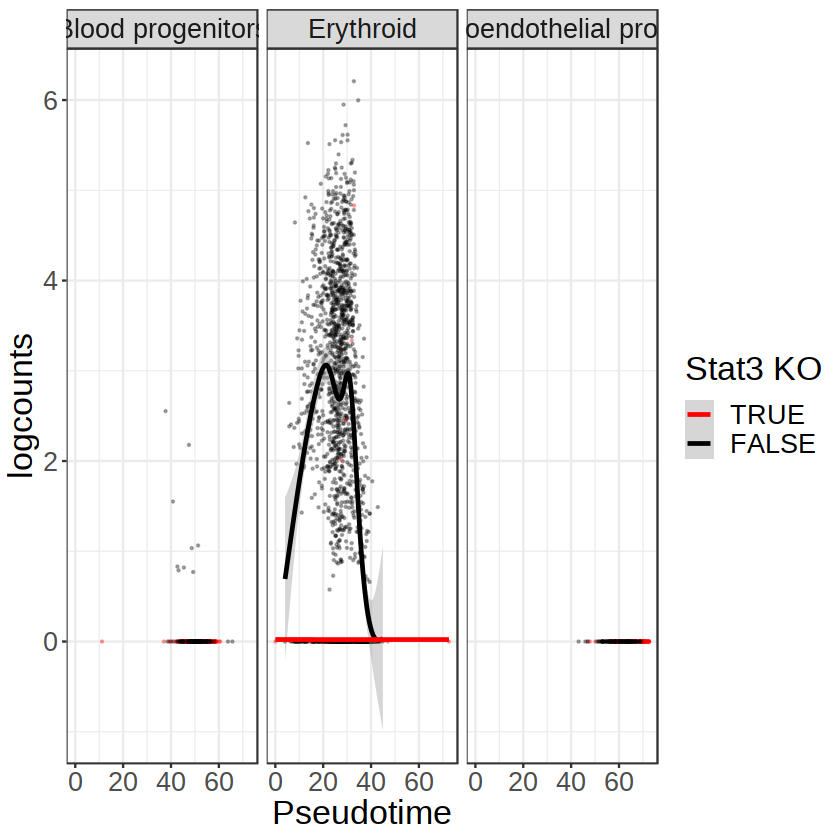

In [207]:
ggplot(as.data.frame(colData(sce_filt)[,-20]), aes(slingPseudotime_1, as.vector(logcounts(sce_filt['Krt15',])), col=tdTom_corr)) + 
    geom_point(size=0.2, alpha=0.3) + 
    geom_smooth() + 
    scale_colour_manual(values=c('TRUE'='red', 'FALSE'='black'), name='Stat3 KO') + 
    ylab('logcounts') + 
    xlab('Pseudotime') + 
    facet_wrap(~celltype.mapped_mnn) + 
    theme_bw() + 
    theme(text=element_text(size=20))

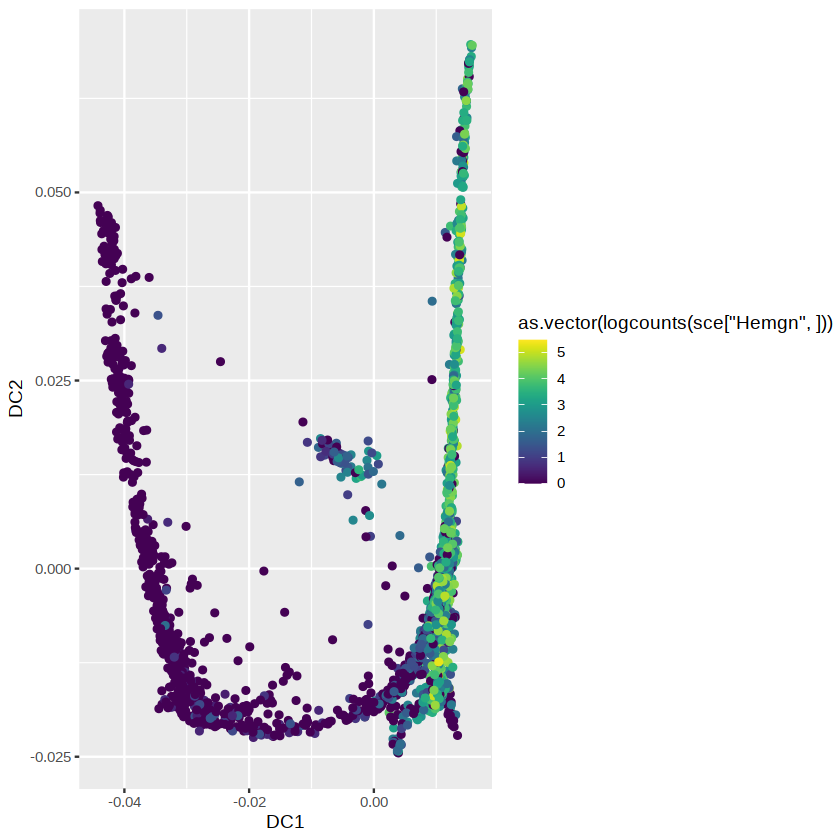

In [202]:
ggplot(as.data.frame(dm@eigenvectors[,c(1,2)]), aes(DC1, DC2, col=as.vector(logcounts(sce['Hemgn',])))) + geom_point() + viridis::scale_color_viridis()

In [160]:
sce_filt

class: SingleCellExperiment 
dim: 5000 3174 
metadata(0):
assays(2): counts logcounts
rownames(5000): Mgst3 Car2 ... Creb1 Mettl21a
rowData names(0):
colnames(3174): SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1
  SLX-21143_SITTA2_HTJH3DSX2#AAACGAACACACCAGC-1 ...
  SLX-21143_SITTH3_HTJH3DSX2#TTTCGATAGCTCATAC-1
  SLX-21143_SITTH3_HTJH3DSX2#TTTGGTTGTTAGCTAC-1
colData names(21): sample barcode ... slingshot slingPseudotime_1
reducedDimNames(2): DiffusionMap PCA
mainExpName: RNA
altExpNames(0):

In [65]:
sce_test = sce_test[1:100]

In [69]:
test <- fitGAM(counts = counts(sce_test), pseudotime = sce_test$slingPseudotime_1, cellWeights = cellWeights, conditions= as.factor(sce_test$tdTom_corr),
                 nknots = 6, verbose = FALSE)

Fitting lineages with multiple conditions. This method has been tested on a couple of datasets, but is still in an experimental phase.



In [72]:
condRes <- conditionTest(test, l2fc = 0.5)
condRes$padj <- p.adjust(condRes$pvalue, "fdr")

In [73]:
condRes = condRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>%
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] %>%
    .[order(padj, -waldStat)]

In [74]:
head(condRes, 10)

gene,waldStat,df,pvalue,padj,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Grb10,96.90026,4,0.000000e+00,0.000000e+00,TRUE
Cd59a,79.05671,5,1.332268e-15,3.274714e-12,TRUE
H19,66.40811,4,1.298961e-13,2.128564e-10,TRUE
Mt1,45.18873,5,1.328181e-08,1.632334e-05,TRUE
Pim1,39.07349,5,2.295308e-07,2.256747e-04,TRUE
Csf2rb,30.94710,4,3.138412e-06,2.571405e-03,TRUE
Xist,29.10983,4,7.425898e-06,5.215102e-03,TRUE
Fabp5,28.01878,5,3.609242e-05,2.217879e-02,TRUE
Hist1h4i,23.28706,4,1.109553e-04,6.060623e-02,FALSE


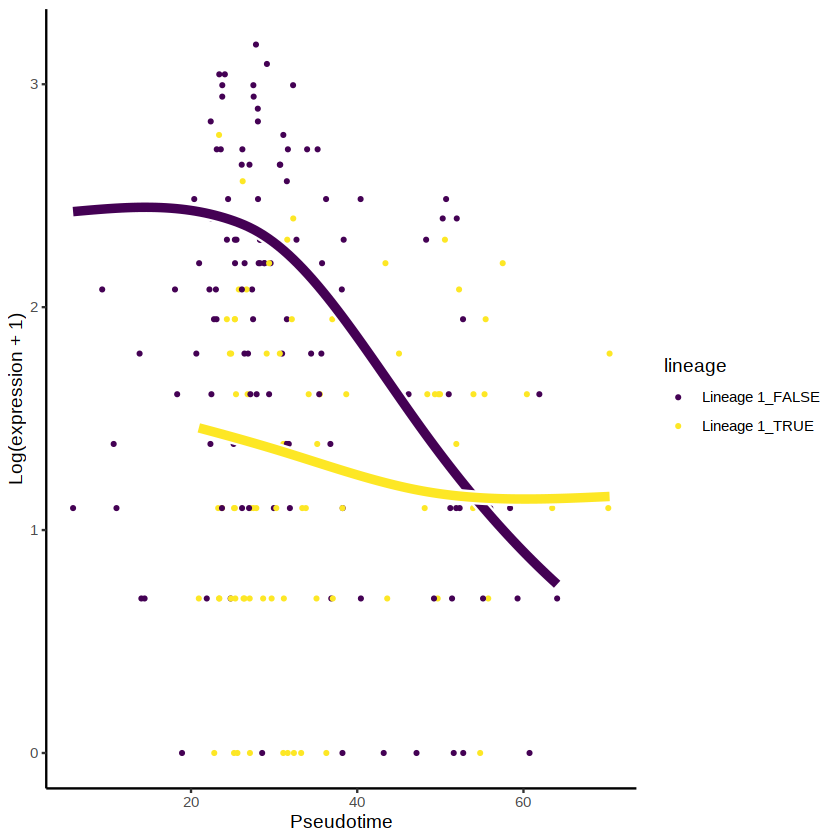

In [78]:
plotSmoothers(test, as.matrix(assays(test)$counts), 'Pim1')

In [71]:
test

class: SingleCellExperiment 
dim: 5000 200 
metadata(1): tradeSeq
assays(1): counts
rownames(5000): Mgst3 Car2 ... Creb1 Mettl21a
rowData names(1): tradeSeq
colnames(200): SLX-21143_SITTB2_HTJH3DSX2#GGATGTTAGAGCAGTC-1
  SLX-21143_SITTG1_HTJH3DSX2#AGGTCTAAGGGATCGT-1 ...
  SLX-21143_SITTH1_HTJH3DSX2#AACACACAGCACGATG-1
  SLX-21143_SITTA2_HTJH3DSX2#GTCAAGTCATAAGCGG-1
colData names(2): crv tradeSeq
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [97]:
sce <- fitGAM(counts = counts(sce.sling), pseudotime = sce.sling$slingPseudotime_1, cellWeights = cellWeights, conditions= as.factor(sce.sling$tdTom_corr),
                 nknots = 6, verbose = FALSE)

Fitting lineages with multiple conditions. This method has been tested on a couple of datasets, but is still in an experimental phase.



In [100]:
condRes <- conditionTest(sce, l2fc = 0.5)
condRes$padj <- p.adjust(condRes$pvalue, "fdr")

In [111]:
condRes = condRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>%
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] %>%
    .[order(padj, -waldStat)]

In [115]:
head(condRes, 10)

gene,waldStat,df,pvalue,padj,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
H19,650.3163,3,0,0,TRUE
Hba-x,442.2575,3,0,0,TRUE
Xist,399.0464,5,0,0,TRUE
Hist1h4i,242.8423,3,0,0,TRUE
Hbb-bh1,213.8702,2,0,0,TRUE
Hbb-y,194.7258,3,0,0,TRUE
Akr1e1,169.1717,4,0,0,TRUE
Hba-a1,158.8680,3,0,0,TRUE
AY036118,148.0823,4,0,0,TRUE


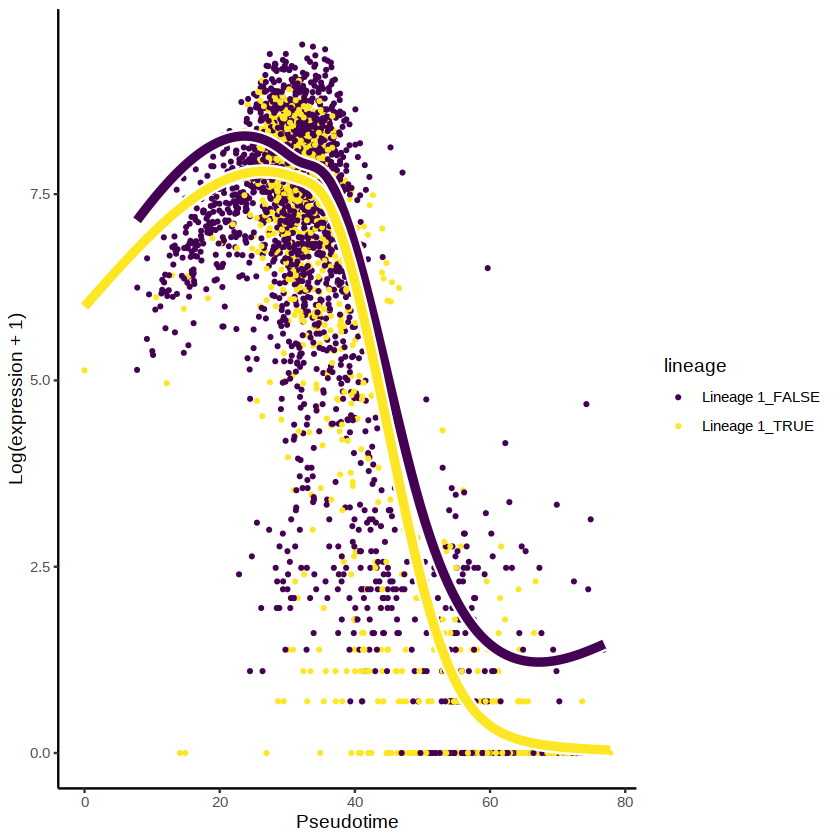

In [122]:
plotSmoothers(sce, as.matrix(assays(sce)$counts), 'Hbb-y')

In [99]:
colData(sce)

DataFrame with 3174 rows and 2 columns
                                                      crv
                                              <DataFrame>
SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1   26.2658:1
SLX-21143_SITTA2_HTJH3DSX2#AAACGAACACACCAGC-1   29.3536:1
SLX-21143_SITTA2_HTJH3DSX2#AAACGAAGTGATAGTA-1   35.1947:1
SLX-21143_SITTA2_HTJH3DSX2#AAACGCTGTATAGCTC-1   35.7706:1
SLX-21143_SITTA2_HTJH3DSX2#AAAGAACGTACGTGTT-1   32.5527:1
...                                                   ...
SLX-21143_SITTH3_HTJH3DSX2#TTGCTGCTCAGACTGT-1   62.3680:1
SLX-21143_SITTH3_HTJH3DSX2#TTTACTGAGGAGAGTA-1   26.3732:1
SLX-21143_SITTH3_HTJH3DSX2#TTTATGCTCCTAAGTG-1   22.0558:1
SLX-21143_SITTH3_HTJH3DSX2#TTTCGATAGCTCATAC-1   22.2839:1
SLX-21143_SITTH3_HTJH3DSX2#TTTGGTTGTTAGCTAC-1   21.3158:1
                                                                                              tradeSeq
                                                                                              <tbl_df>
S

In [ ]:
test = conditionTest(sce, 

In [ ]:
startRes <- startVsEndTest(sce)